In [1]:
import pandas as pd
import numpy as np
import os


In [2]:
master = os.path.join('..', 'data', 'MASTER.xlsx')

df = pd.read_excel(master)

In [3]:
df.head()

,message_text,palabras_activas,label_regla,golden_label,extra
0,Hola buenas una consulta yo estoy matriculado ...,"['presencial', 'consulta', 'alumno']",modalidad_curso,otros,NaN
1,"Buenas tardes, este curso personalizado se pue...","['curso', 'online']",modalidad_curso,curso_especifico,NaN
2,Hola! Quería preguntar sobre las clases online...,"['clase', 'online', 'sobre', 'como', 'comenzar...",modalidad_curso,modalidad,NaN
3,"Hola, para realizar cotizaciones es posible ha...","['presencial', 'realizar']",modalidad_curso,info_general,NaN
4,Quisiera cotizar por un curso en modalidad grupal,"['curso', 'modalidad']",modalidad_curso,precio_curso,curso_por_perfil


In [4]:
df = df.dropna(subset=["message_text", "golden_label"])
df = df.reset_index(drop=True)
df = df[df["golden_label"] != "basura"]

In [5]:
labels_a_fusionar = [
    "examen",
    "canal_contacto",
    "curso_especifico",
    "modalidad",
    "otros"
]

df["golden_label"] = df["golden_label"].replace(labels_a_fusionar, "info_general")

<Axes: ylabel='golden_label'>

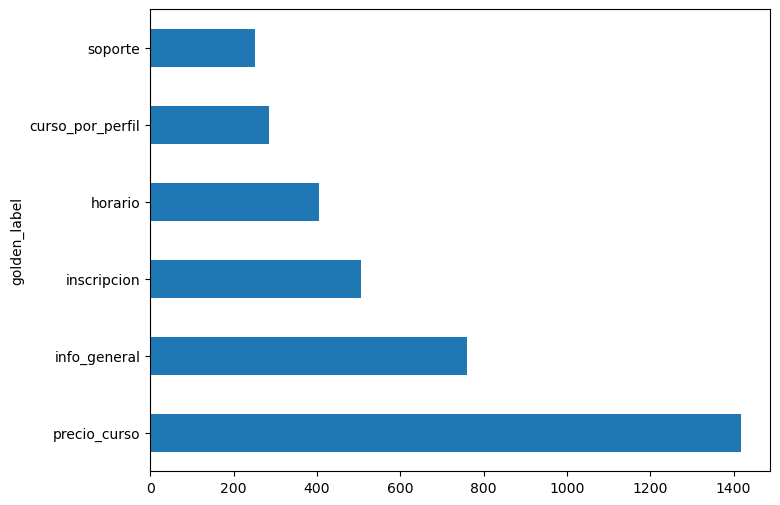

In [6]:
df["golden_label"].value_counts().plot(kind="barh", figsize=(8,6))

In [7]:
import re

def clean_text(text):

    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-záéíóúñ0-9 ]", " ", text)
    text = re.sub(r"\s+", " ", text)

    return text.strip()

df["text_clean"] = df["message_text"].apply(clean_text)

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df["text_clean"],
    df["golden_label"],
    test_size=0.2,
    stratify=df["golden_label"],
    random_state=42
)

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=3
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [10]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=300,
    n_jobs=-1
)

model.fit(X_train_vec, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,300
,multi_class,'deprecated'


In [11]:
from sklearn.metrics import classification_report

pred = model.predict(X_test_vec)

print(classification_report(y_test, pred))

                  precision    recall  f1-score   support

curso_por_perfil       0.67      0.51      0.58        57
         horario       0.65      0.58      0.61        81
    info_general       0.57      0.71      0.63       152
     inscripcion       0.70      0.62      0.66       101
    precio_curso       0.86      0.92      0.89       284
         soporte       0.74      0.34      0.47        50

        accuracy                           0.73       725
       macro avg       0.70      0.61      0.64       725
    weighted avg       0.73      0.73      0.72       725



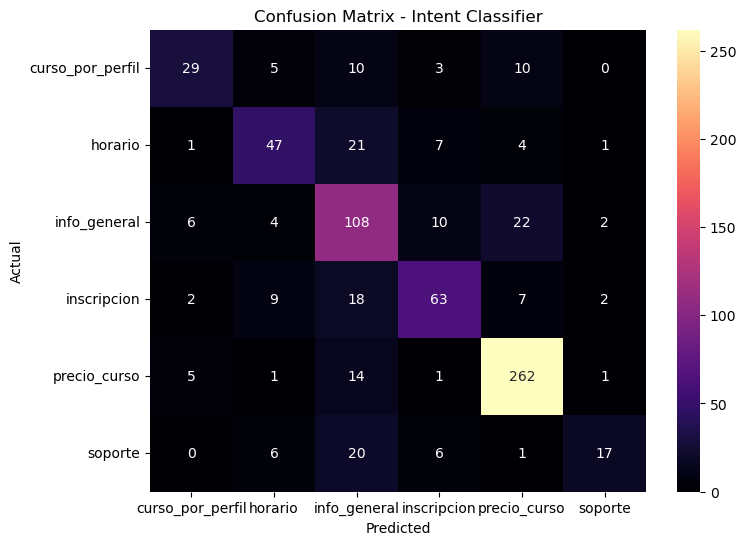

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

labels = sorted(df["golden_label"].unique())

cm = confusion_matrix(y_test, pred, labels=labels)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="magma",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Intent Classifier")

plt.show()

In [13]:
import numpy as np
import pandas as pd

feature_names = vectorizer.get_feature_names_out()

for i, label in enumerate(model.classes_):

    coef = model.coef_[i]

    top = np.argsort(coef)[-15:]

    print(f"\nIntent: {label}")
    print("-"*40)

    for j in reversed(top):
        print(feature_names[j], round(coef[j],3))


Intent: curso_por_perfil
----------------------------------------
años 4.169
para 2.455
edad 2.309
niños 2.306
mi 1.88
adultos 1.786
para niños 1.546
hijo 1.52
adulto 1.51
de años 1.492
que edad 1.388
para adultos 1.35
hija 1.348
com 1.334
10 1.327

Intent: horario
----------------------------------------
horarios 2.967
horario 2.533
las 2.197
los horarios 2.173
fecha 2.144
cuando 2.144
el horario 1.931
comienzan 1.865
clases 1.655
semana 1.261
día 1.229
los 1.201
clases en 1.145
por semana 1.116
martes 1.113

Intent: info_general
----------------------------------------
online 1.89
cae 1.619
modalidad 1.562
certificación 1.551
info 1.497
presenciales 1.382
sobre 1.359
examen 1.276
con 1.255
el examen 1.213
precios horarios 1.182
preparación 1.18
comprar 1.165
cursos 1.133
ielts 1.127

Intent: inscripcion
----------------------------------------
inscribirme 3.123
entrevista 2.306
hora 2.2
matricular 2.175
matricularme 2.158
ir 1.977
evaluación 1.92
inscribir 1.825
hasta 1.759
matricul

In [14]:
import joblib

joblib.dump(model, "../models/intent_model.pkl")
joblib.dump(vectorizer, "../models/vectorizer.pkl")

['../models/vectorizer.pkl']

In [15]:
import json

labels = model.classes_.tolist()

with open("../models/intent_labels.json", "w") as f:
    json.dump(labels, f)

In [16]:
import joblib

model_loaded = joblib.load("../models/intent_model.pkl")
vectorizer_loaded = joblib.load("../models/vectorizer.pkl")

print(model_loaded.classes_)

['curso_por_perfil' 'horario' 'info_general' 'inscripcion' 'precio_curso'
 'soporte']


In [17]:
def test(text):

    vec = vectorizer_loaded.transform([text])

    probs = model_loaded.predict_proba(vec)

    idx = probs.argmax()

    intent = model_loaded.classes_[idx]

    return intent, probs.max()

test("hola cuanto cuesta el curso")

('precio_curso', 0.639321340522044)